## Mount Google Drive & Import Libraries

In [1]:
# ============================
# 1. MOUNT GOOGLE DRIVE (if using Colab)
# ============================
from google.colab import drive
drive.mount('/content/drive')

# ============================
# 2. IMPORT LIBRARIES
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

Mounted at /content/drive
✅ Libraries imported successfully!


## Load the Dataset

In [2]:
# ============================
# 3. LOAD DATASET FROM GOOGLE DRIVE
# ============================
file_path = '/content/drive/MyDrive/DataSet/Telco_Cusomer_Churn.csv'   # ← Make sure this path is 100% correct

df = pd.read_csv(file_path)

print("✅ File loaded successfully!")
print(f"Shape of raw dataset: {df.shape}")
print("\nExact column names:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nMissing values per column:")
print(df.isnull().sum())

✅ File loaded successfully!
Shape of raw dataset: (7043, 21)

Exact column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 3 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No           

## Dataset Description & Initial Exploration

In [3]:
# ============================
# 4. DATASET DESCRIPTION & EXPLORATION (Keep as is, or add this note)
# ============================
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution (Churn):")
print(df['Churn'].value_counts(normalize=True) * 100)

print("\n⚠️ Note: Dataset is imbalanced (73.46% No Churn vs 26.54% Churn). We will use SMOTE on training data only.")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

## Data Preprocessing

In [4]:
# ============================
# 5. IMPROVED DATA PREPROCESSING + SAVE PROCESSED DATA
# ============================

print("Original shape before preprocessing:", df.shape)

# 1. Drop customerID
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
elif 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

# 2. Fix TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 3. Convert Churn to numeric
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("Shape after basic cleaning:", df.shape)

# 4. Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# 5. Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns being encoded:", categorical_cols)

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

print("\n✅ Preprocessing completed!")
print(f"Final feature shape: {X.shape}")

# ============================
# 6. SAVE THE PROCESSED DATASET (Before Split)
# ============================
processed_df = X.copy()
processed_df['Churn'] = y
processed_path = '/content/drive/MyDrive/processed_telco_churn.csv'
processed_df.to_csv(processed_path, index=False)

print(f"\n✅ Processed dataset saved at: {processed_path}")

Original shape before preprocessing: (7043, 21)
Shape after basic cleaning: (7043, 20)
Categorical columns being encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Preprocessing completed!
Final feature shape: (7043, 19)

✅ Processed dataset saved at: /content/drive/MyDrive/processed_telco_churn.csv


## Train-Test Split

In [5]:
# ============================
# 7. TRAIN-TEST SPLIT (Before SMOTE!)
# ============================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]} | Churn rate: {y_train.mean():.4f}")
print(f"Testing samples : {X_test.shape[0]}  | Churn rate: {y_test.mean():.4f}")

Training samples: 5634 | Churn rate: 0.2654
Testing samples : 1409  | Churn rate: 0.2654


6. Random Forest Model – Justification & Background
Why Random Forest?

It is an ensemble learning method (bagging) that builds multiple decision trees and merges them.
Excellent for mixed data types (categorical + numerical) – no need for scaling.
Reduces overfitting compared to a single Decision Tree.
Provides feature importance (very useful for business insights on churn).
Handles class imbalance reasonably well.

Background: Introduced by Leo Breiman (2001). It uses bootstrap sampling + random feature selection at each split.

In [6]:
# ============================
# 8. APPLY SMOTE ONLY ON TRAINING SET
# ============================
from imblearn.over_sampling import SMOTE

print("Before SMOTE - Training class distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE - Training class distribution:")
print(y_train_resampled.value_counts())

print(f"\nNew training shape after SMOTE: {X_train_resampled.shape}")

Before SMOTE - Training class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE - Training class distribution:
Churn
0    4139
1    4139
Name: count, dtype: int64

New training shape after SMOTE: (8278, 19)


In [12]:
# ============================
# 9. TRAIN RANDOM FOREST ON RESAMPLED DATA
# ============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    # class_weight='balanced'  # You can keep or remove since SMOTE already balances
)

rf_model.fit(X_train_resampled, y_train_resampled)

import joblib

# Save the model
joblib.dump(rf_model, '/content/drive/MyDrive/random_forest_churn_model_smote.pkl')

# Save all LabelEncoders
joblib.dump(le_dict, '/content/drive/MyDrive/label_encoders.pkl')

print("✅ Model and LabelEncoders saved successfully!")

print("✅ Random Forest model trained on SMOTE-balanced data!")

✅ Model and LabelEncoders saved successfully!
✅ Random Forest model trained on SMOTE-balanced data!


## Results & Evaluation

✅ Accuracy          : 0.7651
ROC-AUC Score       : 0.8304

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.55      0.62      0.58       374

    accuracy                           0.77      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



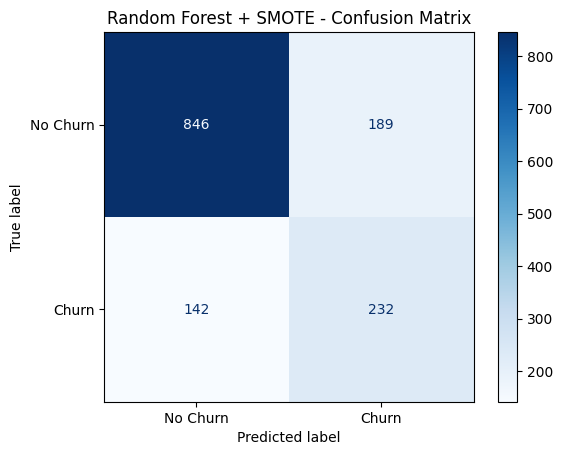

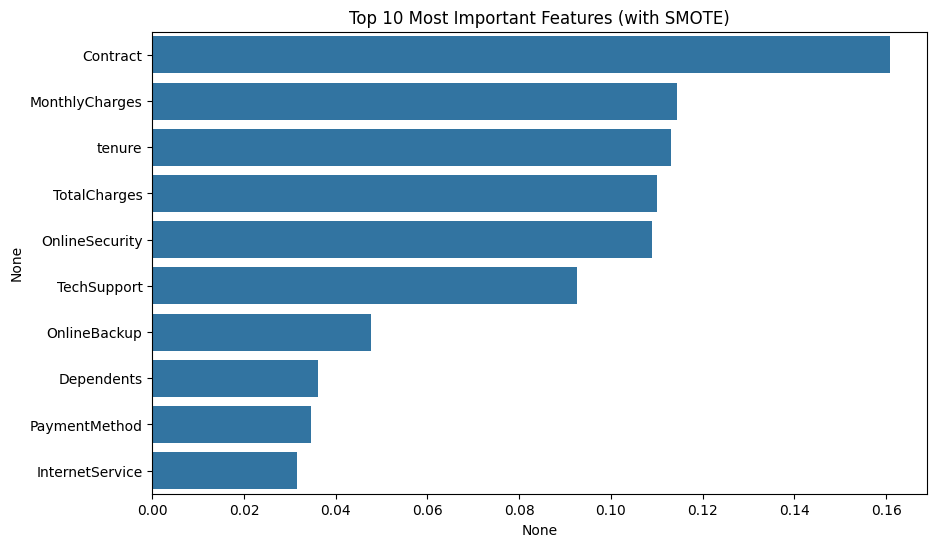

In [13]:
# ============================
# 10. RESULTS & EVALUATION (On Original Test Set)
# ============================
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"✅ Accuracy          : {accuracy:.4f}")
print(f"ROC-AUC Score       : {roc_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Random Forest + SMOTE - Confusion Matrix')
plt.show()

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[:10], y=importances.index[:10])
plt.title('Top 10 Most Important Features (with SMOTE)')
plt.show()

## Save Model & Notebook Tips

In [14]:
import joblib
joblib.dump(rf_model, '/content/drive/MyDrive/random_forest_churn_model.pkl')
print("✅ Model with SMOTE saved!")

✅ Model with SMOTE saved!
